In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [75]:
try:
    df = pd.read_csv(r"C:\Users\ADMIN\Desktop\Datasets\owid-covid-data.csv")
                     
except FileNotFoundError:
    print("Error: File not found.")
except pd.errors.ParserError:
    print("Error: Failed to parse CSV file.")
except Exception as e:
    print(f"Unexpected error: {e}")                     

In [76]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,1/3/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,1/4/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,1/5/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,1/6/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,1/7/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN


In [77]:
column_list = df.columns.tolist()
print(column_list)

['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'total_

In [78]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,3.120880e+05,3.404570e+05,3.391980e+05,2.905010e+05,340511.000000,339281.000000,312088.000000,340457.000000,339198.000000,290501.000000,...,200889.000000,132973.000000,239669.000000,322072.000000,263138.000000,3.500850e+05,1.218400e+04,12184.000000,12184.000000,12184.000000
mean,6.683354e+06,9.601634e+03,9.637066e+03,8.602180e+04,85.511055,85.817071,101749.851259,145.163814,145.696924,872.289356,...,32.909483,50.789962,3.097245,73.713631,0.722464,1.284633e+08,5.281637e+04,9.738648,11.345256,1669.025575
std,4.068903e+07,1.102769e+05,9.447784e+04,4.398873e+05,613.687971,559.130004,151265.689121,1163.714678,599.957847,1100.189784,...,13.573767,31.956100,2.548327,7.395220,0.148976,6.607694e+08,1.492195e+05,12.304441,25.181297,1938.556228
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.394000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2752.924800
25%,8.090000e+03,0.000000e+00,2.860000e-01,1.270000e+02,0.000000,0.000000,2595.577500,0.000000,0.044000,60.606000,...,22.600000,20.859000,1.300000,69.590000,0.602000,4.490020e+05,1.202250e+02,1.400000,-1.600000,72.395046
50%,7.020500e+04,2.000000e+00,2.485700e+01,1.328000e+03,0.000000,0.143000,28307.659000,0.128000,6.517000,377.169000,...,33.100000,49.839000,2.500000,75.050000,0.740000,5.882259e+06,5.885850e+03,8.075000,5.720000,1105.404700
75%,7.409558e+05,2.640000e+02,4.978570e+02,1.192200e+04,3.000000,5.143000,133506.244000,35.466000,82.411000,1365.925000,...,41.300000,82.502000,4.200000,79.460000,0.829000,2.830170e+07,3.742344e+04,15.360000,16.302500,2740.130200
max,7.714071e+08,8.401961e+06,6.402036e+06,6.972139e+06,27939.000000,14822.000000,737554.506000,228872.025000,37241.781000,6511.209000,...,78.100000,100.000000,13.800000,86.750000,0.957000,7.975105e+09,1.289776e+06,76.620000,377.630000,10292.916000


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  object 
 1   continent                                   333420 non-null  object 
 2   location                                    350085 non-null  object 
 3   date                                        350085 non-null  object 
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 

In [80]:
df.isnull().sum()

iso_code                                        0
continent                                   16665
location                                        0
date                                            0
total_cases                                 37997
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_per_million    337901
Length: 67, dtype: int64

In [81]:
# selecting countries of interest from the dataset
countries_of_interest = ['Kenya', 'America','India']
df = df[df['location'].isin(countries_of_interest)]
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
139773,IND,Asia,India,1/3/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139774,IND,Asia,India,1/4/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139775,IND,Asia,India,1/5/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139776,IND,Asia,India,1/6/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139777,IND,Asia,India,1/7/2020,NaN,0.0,NaN,NaN,0.0,NaN,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN


In [82]:
df.isnull().sum()

iso_code                                      0
continent                                     0
location                                      0
date                                          0
total_cases                                 103
                                           ... 
population                                    0
excess_mortality_cumulative_absolute       2775
excess_mortality_cumulative                2775
excess_mortality                           2775
excess_mortality_cumulative_per_million    2775
Length: 67, dtype: int64

In [83]:
# dropping rows with missing dates and total_cases 
df = df.dropna(subset = ['date','total_cases'])

In [84]:
#convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

In [85]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
139800,IND,Asia,India,2020-01-30,1.0,1.0,0.143,NaN,0.0,0.0,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139801,IND,Asia,India,2020-01-31,5.0,4.0,0.714,NaN,0.0,0.0,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139802,IND,Asia,India,2020-02-01,5.0,0.0,0.714,NaN,0.0,0.0,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139803,IND,Asia,India,2020-02-02,2.0,NaN,NaN,NaN,0.0,0.0,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN
139804,IND,Asia,India,2020-02-03,3.0,1.0,0.857,NaN,0.0,0.0,...,20.6,59.55,0.53,69.66,0.645,1417173120,NaN,NaN,NaN,NaN


In [86]:
# checking missing columns and printing only columns with at least one missing value
missing = df.isnull().sum()
missing_column = missing[missing > 0]

print("Columns with missing values :\n")
print(missing_column)

Columns with missing values :

new_cases                                        3
new_cases_smoothed                               3
total_deaths                                    56
new_cases_per_million                            3
new_cases_smoothed_per_million                   3
total_deaths_per_million                        56
reproduction_rate                              643
icu_patients                                  2672
icu_patients_per_million                      2672
hosp_patients                                 2672
hosp_patients_per_million                     2672
weekly_icu_admissions                         2672
weekly_icu_admissions_per_million             2672
weekly_hosp_admissions                        2672
weekly_hosp_admissions_per_million            2672
total_tests                                   1591
new_tests                                     1693
total_tests_per_thousand                      1591
new_tests_per_thousand                        1693


In [87]:
# selecting numerical values
numerical_cols = df.select_dtypes(include = ['float64','int64']).columns

# interpolate missing values in numerical columns
df[numerical_cols] = df[numerical_cols].interpolate(limit_direction = 'both')

In [88]:
# checking missing columns with at least one missing value after interpolating
missing = df.isnull().sum()
missing_column = missing[missing > 0]

print("Columns with missing values :\n")
print(missing_column)

Columns with missing values :

icu_patients                               2672
icu_patients_per_million                   2672
hosp_patients                              2672
hosp_patients_per_million                  2672
weekly_icu_admissions                      2672
weekly_icu_admissions_per_million          2672
weekly_hosp_admissions                     2672
weekly_hosp_admissions_per_million         2672
tests_units                                1010
excess_mortality_cumulative_absolute       2672
excess_mortality_cumulative                2672
excess_mortality                           2672
excess_mortality_cumulative_per_million    2672
dtype: int64


In [89]:
# filling remaining missing values with fillna()
fill_strategies = {
    'icu_patients' : 'mean',
    'icu_patients_per_million'  : 'mean',
    'hosp_patients' : 'mean',
    'hosp_patients_per_million' : 'mean',
    'weekly_icu_admissions' : 'mean',
    'weekly_icu_admissions_per_million' : 'mean',
    'weekly_hosp_admissions' : 'median',
    'weekly_hosp_admissions_per_million' : 'median',
    'tests_units' : 'mode',
    'excess_mortality_cumulative_absolute' : 'median',
    'excess_mortality_cumulative' : 'median',
    'excess_mortality' : 'median',
    'excess_mortality_cumulative_per_million' : 'mean'

}
for col, strategy in fill_strategies.items():
    if strategy == 'mean':
        df[col] = df[col].fillna(df[col].mean())
    elif strategy == 'median':
        df[col] = df[col].fillna(df[col].median())
    elif strategy == 'mode':
        df[col] = df[col].fillna(df[col].mode()[0])

for col in fill_strategies:
    if col in df.columns:
        df[col] = df[col].fillna(0)



In [90]:
df.isnull().sum()

iso_code                                   0
continent                                  0
location                                   0
date                                       0
total_cases                                0
                                          ..
population                                 0
excess_mortality_cumulative_absolute       0
excess_mortality_cumulative                0
excess_mortality                           0
excess_mortality_cumulative_per_million    0
Length: 67, dtype: int64

In [91]:
plt.figure(figsize = (10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

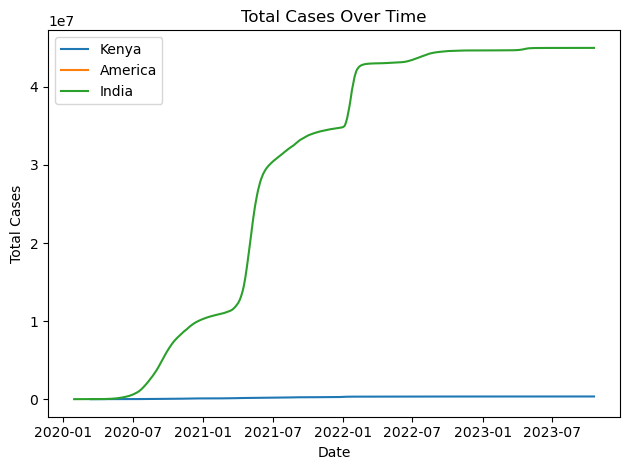

In [92]:
# total cases over time
for country in countries_of_interest:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'],country_df['total_cases'],label = country)
plt.title('Total Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.legend()
plt.tight_layout()
plt.show()

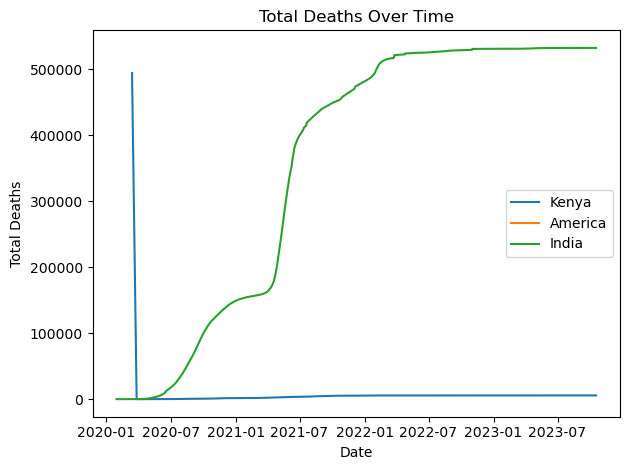

In [93]:
# total deaths over time
for country in countries_of_interest:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'],country_df['total_deaths'],label = country)
plt.title('Total Deaths Over Time')
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.legend()
plt.tight_layout()
plt.show()

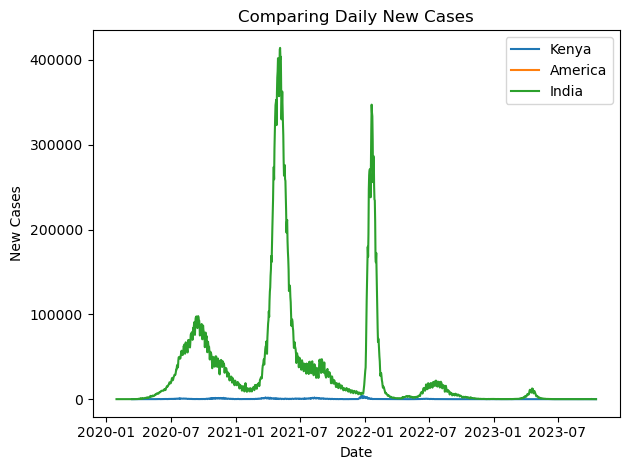

In [94]:
# compare new cases 
for country in countries_of_interest:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'],country_df['new_cases'],label = country)
plt.title('Comparing Daily New Cases')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
df['death_rate'] = df['total_deaths'] / df['total_cases']
print(df['death_rate'])

139800    1.000000
139801    0.200000
139802    0.200000
139803    0.500000
139804    0.333333
            ...   
159167    0.016538
159168    0.016538
159169    0.016538
159170    0.016538
159171    0.016538
Name: death_rate, Length: 2672, dtype: float64


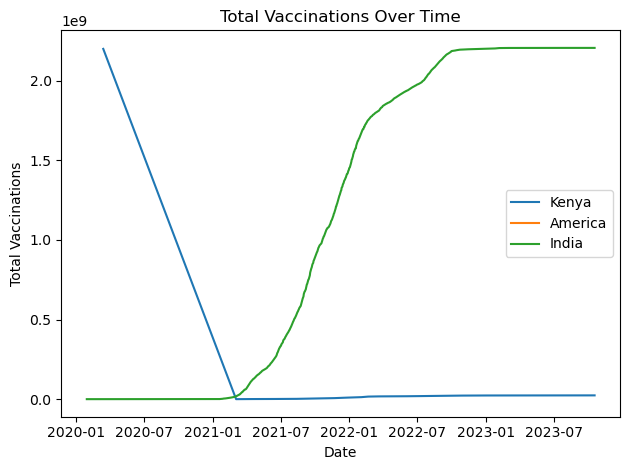

In [96]:
# total vaccinations over time 
for country in countries_of_interest:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'],country_df['total_vaccinations'],label = country)
plt.title('Total Vaccinations Over Time')
plt.xlabel('Date')
plt.ylabel('Total Vaccinations')
plt.legend()
plt.tight_layout()
plt.show()

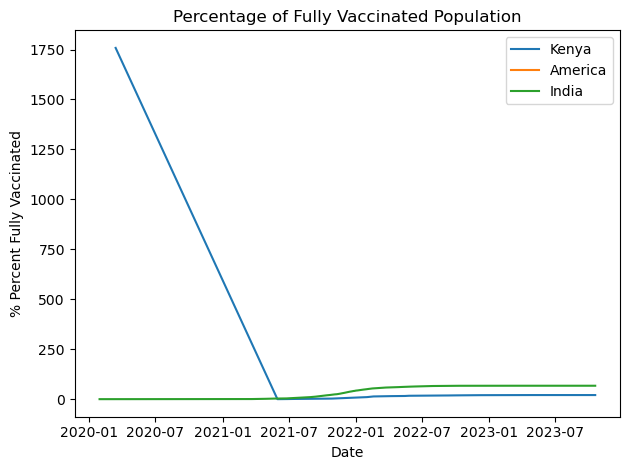

In [97]:
df['percent_vaccinated'] = (df['people_fully_vaccinated'] / df['population']) * 100
# total vaccinations over time 
for country in countries_of_interest:
    country_df = df[df['location'] == country]
    plt.plot(country_df['date'],country_df['percent_vaccinated'],label = country)
plt.title('Percentage of Fully Vaccinated Population')
plt.xlabel('Date')
plt.ylabel('% Percent Fully Vaccinated')
plt.legend()
plt.tight_layout()
plt.show()

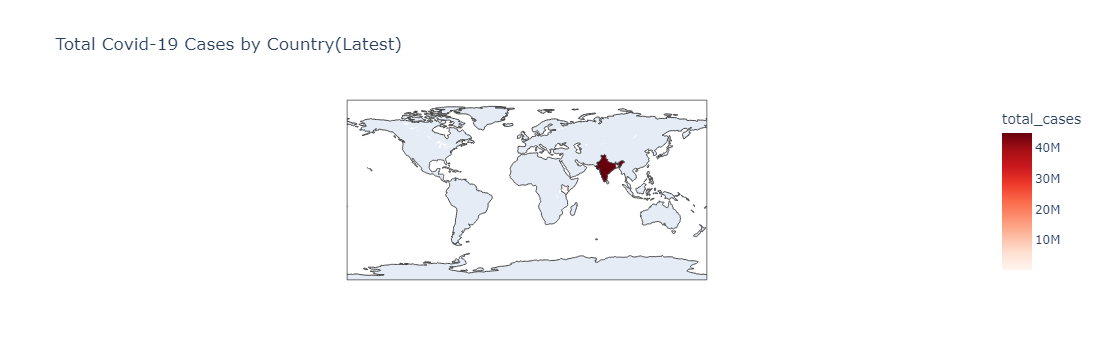

In [98]:
# Choropleth
import plotly.express as px
# get latest data for each country
latest_data = df[df['date'] == df['date'].max()]

# plot choropleth
fig = px.choropleth(latest_data,
                    locations = "iso_code",
                    color = "total_cases",
                    hover_name = "location",
                    color_continuous_scale = "Reds",
                    title = "Total Covid-19 Cases by Country(Latest)")
fig.show()

###  Insight 1: India recorded the highest number of total COVID-19 cases.
From the choropleth map and bar plots, **India** had the **highest total number of COVID-19 cases** among the selected countries, followed closely by the **United States**.


###  Insight 2: Kenya had significantly fewer total cases and deaths.
Despite being affected by the pandemic, Kenya’s total cases and deaths were much lower compared to India and the United States, likely due to differences in population size, testing capacity, or reporting coverage.

###  Insight 3: The United States had the highest death rate.
When comparing the death rate (total deaths / total cases), the United States showed a notably higher death rate, indicating either more severe outbreaks, older population, or healthcare strain.


### Insight 4: Daily new cases peaked at different times.
The daily new cases plot showed that India’s cases peaked sharply around mid-2021 (Delta variant wave), while the U.S. experienced multiple surges. Kenya’s daily cases remained relatively low, with smaller spikes.

###  Insight 5: Vaccination rollout was uneven across countries.
The United States had a faster and broader vaccine rollout, while Kenya's vaccination progress was much slower, highlighting a global disparity in vaccine distribution.